# Phase-contrast: encoding velocity into phase

A gradient echo measures how much signal a voxel has, not how fast it is moving. **Velocity
encoding** adds a pair of gradient lobes that leave still spins exactly as they were and give
moving spins a phase proportional to their speed:

```text
-A          +A
____        ####          two lobes, equal area, opposite polarity
    \      /
     \____/               net area zero, first moment not zero
```

A spin standing still sees the two lobes cancel and comes out with the phase it went in with. A
spin moving along the axis is somewhere else during the second lobe than it was during the first,
so the two no longer cancel and it comes out ahead — by an amount proportional to its velocity.

One acquisition is not enough, because a real voxel's phase also contains coil phase,
off-resonance and susceptibility, none of which is velocity. So the pair is played **twice with
opposite sign**, and the two acquisitions are subtracted:

$$\Delta\phi \;=\; 2\pi \, \Delta m_1 \, v, \qquad \Delta m_1 = \frac{1}{2\,\texttt{venc\_m\_s}}$$

Everything that is not velocity is identical in the two and cancels. `venc_m_s` is defined as the
velocity that makes $\Delta\phi$ exactly $\pi$.

`sc.modules.VelocityEncode` is that pair. This notebook builds it, checks what it emits, and puts
it inside a gradient-echo repetition.

| | |
|---|---|
| **1** | what the pair is made of, and how it adapts to the gradient system |
| **2** | the factor of two, and what `polarity` means |
| **3** | what the emitted waveform says about itself |
| **4** | putting it inside a repetition |
| **5** | the files |

**Output:** two `.seq` files, one per polarity, which
[`02_simulate_and_reconstruct.ipynb`](02_simulate_and_reconstruct.ipynb) plays through a Bloch
simulator with **moving** spins. **Needs nothing but `seqcraft`.**

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

opts = pp.Opts(
    max_grad=40, grad_unit='mT/m',
    max_slew=150, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
)

FOV_MM, MATRIX, THICKNESS_MM = 220.0, 32, 5.0
#: The velocity that makes the phase difference exactly pi.  A protocol sets it somewhat above the
#: fastest flow it expects, because anything faster wraps.
VENC_M_S = 1.0
#: The encoding axis.  Each axis is independent, so through-plane flow is one of these.
AXIS = 'z'
SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)
raster = sc.Raster(opts.grad_raster_time)

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. What the pair is made of

Two trapezoids, equal area, opposite polarity, played back to back. The module solves the
**continuous** problem in closed form from the gradient limits rather than searching: with lobe
area $A$, rise time $r$ and flat time $f$, the two lobe centres are $\Delta T = 2r + f$ apart and

$$|m_1| = A \, \Delta T = \frac{\Delta m_1}{2}$$

There are two regimes and the module decides which applies rather than trying both. When the
target is small enough the lobes are **triangular** and the amplitude is the real root of a cubic;
otherwise the amplitude pins at `max_grad` and a **flat top** grows, as the positive root of a
quadratic.

In [2]:
print(f'{"venc / (m/s)":>13}{"delta_m1 / (s/m)":>18}{"duration / ms":>15}'
      f'{"amplitude / %max":>18}{"rise / us":>11}{"flat / us":>11}  regime')
for venc in (0.1, 0.25, 0.5, 1.0, 2.0, 5.0):
    ve = sc.modules.VelocityEncode(opts=opts, venc_m_s=venc, axis=AXIS)
    regime = 'triangular' if ve.flat_time_s == 0.0 else 'trapezoidal'
    print(f'{venc:13.2f}{ve.delta_m1_s_per_m:18.4f}{ve.duration_s * 1e3:15.3f}'
          f'{ve.amplitude_hz_per_m / opts.max_grad * 100:18.1f}'
          f'{ve.rise_time_s * 1e6:11.0f}{ve.flat_time_s * 1e6:11.0f}  {regime}')

 venc / (m/s)  delta_m1 / (s/m)  duration / ms  amplitude / %max  rise / us  flat / us  regime
         0.10            5.0000          2.720              99.0        270        820  trapezoidal
         0.25            2.0000          1.840              98.2        270        380  trapezoidal
         0.50            1.0000          1.400              97.5        270        160  trapezoidal
         1.00            0.5000          1.100              95.3        270         10  trapezoidal
         2.00            0.2500          0.880              75.8        220          0  triangular
         5.00            0.1000          0.640              57.3        160          0  triangular


A smaller `venc_m_s` is a larger first moment and therefore a longer pair — which is the cost of
measuring slow flow, and it is paid in echo time. The amplitude never reaches 100 % of `max_grad`
because the lobe times are rounded **up** onto the gradient raster and the amplitude is then
solved again against those realised times. Rounding up can only lower the amplitude the target
needs, so the design lands inside the hardware limits rather than outside them, and $\Delta m_1$
comes out exact rather than approximately right.

**What that is not.** Rounding the continuous optimum up is not the same as searching the raster
lattice, so these pairs are legal and exact but not necessarily the shortest legal ones — at
`venc_m_s = 1.0` this design is 1.100 ms and a lattice point exists at 1.080 ms. `VelocityEncode`
makes no minimum-duration claim and publishes no `min_duration_s`; shortening the encoding is the
business of the **merged** designs, which reshape imaging gradients this module does not own.

---
## 2. The factor of two, and what `polarity` means

`venc_m_s` is defined by the **change** in first moment between the two toggles. Each toggle
carries half of it:

```text
delta_m1        = 1 / (2 * venc)        the change across the pair
one toggle's m1 = delta_m1 / 2          which is 1 / (4 * venc)
```

A caller who gives *one* toggle a first moment of $\Delta m_1$ is out by a factor of two, and
gets a perfectly plausible velocity map at half the VENC they asked for. `VelocityEncode` takes
`venc_m_s` and never asks for a moment, so the mistake has nowhere to happen.

**`polarity` is the sign of the emitted first moment** — not the sign of a velocity, and not the
sign of a reconstructed phase. Defining it on the waveform is what makes it checkable: `sc.moments`
reads the sign straight back off the events, and nothing has to agree a convention with a
reconstruction to do it. Which sign of measured flow a reconstruction calls *forward* is its own
choice, downstream of this module.

No $\gamma$ appears anywhere above. SeqCraft's gradients are in Hz/m, so the phase a moving spin
accumulates is $\phi = 2\pi(m_0 x_0 + m_1 v)$ and $\Delta m_1 = 1/(2\,\mathrm{venc})$ holds for any
nucleus. The textbook relation $\Delta m_1 = \pi/(\gamma\,\mathrm{VENC})$ is the same number in
T/m units; the $\gamma$ is the unit conversion.

In [3]:
ve = sc.modules.VelocityEncode(opts=opts, venc_m_s=VENC_M_S, axis=AXIS)

print(f'venc = {ve.venc_m_s} m/s  ->  delta_m1 = {ve.delta_m1_s_per_m} s/m\n')
print(f'{"polarity":>9}{"m0 / (1/m)":>14}{"m1 / (s/m)":>14}{"first lobe":>12}')
for polarity in (+1, -1):
    toggle = ve(polarity=polarity)
    first = sorted(sc.design.logic.flatten(toggle))[0][1]
    print(f'{polarity:+9d}{sc.moments(toggle, 0)[AXIS]:14.2e}{sc.moments(toggle, 1)[AXIS]:14.6f}'
          f'{"negative" if float(first.amplitude) < 0 else "positive":>12}')

delta = (sc.moments(ve(polarity=+1), 1)[AXIS] - sc.moments(ve(polarity=-1), 1)[AXIS])
print(f'\nmeasured change between the toggles  {delta:.6f} s/m')
print(f'1 / (2 * venc)                       {1.0 / (2.0 * VENC_M_S):.6f} s/m')
print(f'one toggle is half of it             {ve.first_moment_s_per_m(+1):.6f} s/m')

venc = 1.0 m/s  ->  delta_m1 = 0.5 s/m

 polarity    m0 / (1/m)    m1 / (s/m)  first lobe
       +1      0.00e+00      0.250000    negative
       -1      0.00e+00     -0.250000    positive

measured change between the toggles  0.500000 s/m
1 / (2 * venc)                       0.500000 s/m
one toggle is half of it             0.250000 s/m


---
## 3. What the emitted waveform says about itself

Three things have to hold, and all three are integrated off the events rather than taken from the
module. `sc.moments` takes no `Opts` and does no compile — a moment is a property of a waveform,
so reading one back is reading what a scanner would play.

**Net area zero.** Otherwise the encoding displaces stationary spins as well, which shows up as a
geometric shift rather than as an obvious error.

**The change in first moment is the one `venc_m_s` implies.** This is the claim the module exists
to make good on, and it is a claim about the *pair*: a module that got both toggles wrong in the
same direction would pass every per-toggle check.

**The first moment does not depend on where the pair is placed.** Once $m_0 = 0$, shifting the
time origin changes $m_1$ by $m_0 \Delta t = 0$. That is why this can be a leaf at all — it can sit
anywhere in a repetition without being told where the echo is.

In [4]:
placed = sc.LogicBlock('probe').add(17e-3, ve(polarity=+1))
alone = sc.LogicBlock('probe').add(0.0, ve(polarity=+1))

print(f'net area, both toggles      '
      f'{[f"{sc.moments(ve(polarity=p), 0)[AXIS]:+.2e}" for p in (1, -1)]}  1/m'
      f'   (lobe area {ve.lobe_area_1_per_m:.1f})')
print(f'change in first moment      {delta:.9f} s/m')
print(f'                            {1.0 / (2.0 * VENC_M_S):.9f} s/m  asked for')
print(f'first moment at t = 0       {sc.moments(alone, 1)[AXIS]:.9f} s/m')
print(f'first moment at t = 17 ms   {sc.moments(placed, 1)[AXIS]:.9f} s/m   <- unchanged')

net area, both toggles      ['+0.00e+00', '+0.00e+00']  1/m   (lobe area 454.5)
change in first moment      0.500000000 s/m
                            0.500000000 s/m  asked for
first moment at t = 0       0.250000000 s/m
first moment at t = 17 ms   0.250000000 s/m   <- unchanged


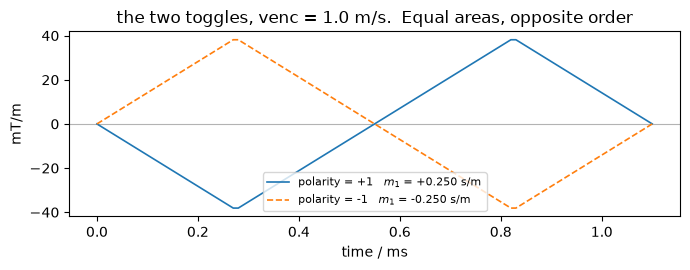

In [5]:
fig, ax = plt.subplots(figsize=(7.0, 2.8))
for polarity, style in ((+1, '-'), (-1, '--')):
    grid, grads, _ = sc.sample(ve(polarity=polarity), opts)
    ax.plot(grid * 1e3, grads[AXIS] / 42.576e6 * 1e3, style, lw=1.2,
            label=f'polarity = {polarity:+d}   $m_1$ = {ve.first_moment_s_per_m(polarity):+.3f} s/m')
ax.axhline(0.0, color='0.7', lw=0.8, zorder=0)
ax.set(xlabel='time / ms', ylabel='mT/m',
       title=f'the two toggles, venc = {VENC_M_S} m/s.  Equal areas, opposite order')
ax.legend(fontsize=8)
fig.tight_layout()

---
## 4. Putting it inside a repetition

The bipolar is a leaf: it knows nothing about what surrounds it and imposes nothing on it. But
there is only one place it can go — **after the excitation, before the echo it is meant to
phase** — so a phase-contrast repetition is an ordinary gradient-echo repetition with the pair
inserted into that gap:

```text
excitation -> [ bipolar ] -> phase encode + readout -> rewinder + spoiler
```

Composing it by hand rather than reaching for a prepackaged kernel is the point of this section:
it shows exactly what the encoding costs, which is its own duration added to the echo time. That
cost is why `venc_m_s` is a protocol decision and not a free parameter.

In [6]:
exc = sc.modules.Excitation(opts=opts, flip_deg=20.0, thickness_mm=THICKNESS_MM, duration_s=1e-3)
pe = sc.modules.PhaseEncode(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, axis='y')
ro = sc.modules.CartesianLine(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, bandwidth_hz_px=500.0)
crush = sc.modules.spoiler(opts, cycles_per_voxel=4.0, voxel_mm=THICKNESS_MM, axis='z')

#: The excitation is over once its slice rephaser is, and only then may the encoding start.
EXC_END_S = float(raster.ceil(max(exc.time_to_rephaser() + exc.rephaser_duration_s,
                                  exc().duration)))
VENC_START_S = EXC_END_S
READOUT_START_S = float(raster.ceil(VENC_START_S + ve.duration_s))
TAIL_S = float(raster.ceil(READOUT_START_S + ro().duration))
TR_S = float(raster.ceil(TAIL_S + crush.duration))


def repetition(line, polarity):
    """One phase-contrast repetition: a gradient echo with the bipolar inserted."""
    return (sc.LogicBlock('pc_gre_tr')
            .add(0.0, exc())
            .add(VENC_START_S, ve(polarity=polarity))
            .add(READOUT_START_S, pe(line=line))
            .add(READOUT_START_S, ro())
            .add(TAIL_S, pe(line=line, rewind=True))
            .add(TAIL_S, crush)
            .add(READOUT_START_S, pp.make_label(type='SET', label='LIN', value=int(line))))


print(f'excitation ends at   {EXC_END_S * 1e3:7.3f} ms')
print(f'bipolar              {ve.duration_s * 1e3:7.3f} ms   <- what the encoding costs')
print(f'readout starts at    {READOUT_START_S * 1e3:7.3f} ms')
print(f'TR                   {TR_S * 1e3:7.3f} ms')
print(f'\nwithout the encoding the readout could start at {EXC_END_S * 1e3:.3f} ms, so the '
      f'pair adds {ve.duration_s * 1e3:.3f} ms to every repetition')

excitation ends at     1.800 ms
bipolar                1.100 ms   <- what the encoding costs
readout starts at      2.900 ms
TR                     5.900 ms

without the encoding the readout could start at 1.800 ms, so the pair adds 1.100 ms to every repetition


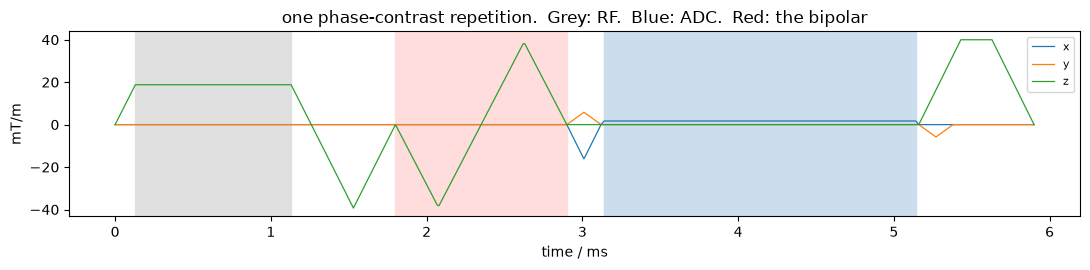

In [7]:
fig, ax = plt.subplots(figsize=(11.0, 2.8))
grid, grads, spans = sc.sample(repetition(MATRIX // 2 + 6, +1), opts)
for axis in ('x', 'y', 'z'):
    if axis in grads:
        ax.plot(grid * 1e3, grads[axis] / 42.576e6 * 1e3, lw=0.9, label=axis)
for kind, start, stop, _path in spans:
    if kind in ('rf', 'adc'):
        ax.axvspan(start * 1e3, stop * 1e3, color='0.88' if kind == 'rf' else '#cde',
                   zorder=0)
ax.axvspan(VENC_START_S * 1e3, (VENC_START_S + ve.duration_s) * 1e3, color='#fdd', zorder=0)
ax.set(xlabel='time / ms', ylabel='mT/m',
       title='one phase-contrast repetition.  Grey: RF.  Blue: ADC.  Red: the bipolar')
ax.legend(fontsize=8, loc='upper right')
fig.tight_layout()

---
## 5. The files

One acquisition per polarity, identical in every other respect — same lines, same order, same
timing. That is what makes the subtraction in `02` cancel everything that is not velocity.

In [8]:
print(f'{"polarity":>9} {"file":>34} {"blocks":>8} {"duration / ms":>14}')
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always', sc.SeqCraftWarning)
    for polarity in (+1, -1):
        tree = sc.LogicBlock('pc_gre')
        for index, line in enumerate(range(MATRIX)):
            tree.add(index * TR_S, repetition(line, polarity))
        name = (f'pc_gre_2d_venc{int(round(VENC_M_S * 100)):03d}_'
                f'{"plus" if polarity > 0 else "minus"}')
        seq = sc.compile(tree, opts, name=name, definitions={
            'FOV': [FOV_MM / 1e3, FOV_MM / 1e3, THICKNESS_MM / 1e3],
            'venc_m_s': VENC_M_S, 'polarity': polarity})
        seq.write(str(SEQ_DIR / f'{name}.seq'))
        print(f'{polarity:+9d} {name + ".seq":>34} {len(seq.block_events):8d} '
              f'{tree.duration * 1e3:14.1f}')

print(f'\n{len(caught)} warnings, every one of them from the imaging train:')
for kind in sorted({str(w.message).split(':')[0] for w in caught}):
    print(f'   {kind}')

np.savez(SEQ_DIR / 'pc_gre_2d_nominal.npz',
         matrix=np.array([MATRIX, MATRIX]), fov_mm=np.array([FOV_MM, FOV_MM]),
         thickness_mm=THICKNESS_MM, venc_m_s=VENC_M_S, axis=AXIS,
         delta_m1_s_per_m=ve.delta_m1_s_per_m, tr_s=TR_S,
         venc_start_s=VENC_START_S, readout_start_s=READOUT_START_S)
print(f'\n-> {SEQ_DIR / "pc_gre_2d_nominal.npz"}')

 polarity                               file   blocks  duration / ms
       +1         pc_gre_2d_venc100_plus.seq      224          188.8


       -1        pc_gre_2d_venc100_minus.seq      224          188.8

2 warnings, every one of them from the imaging train:
   52 blocks over the vector-norm limit (legal on real amplifiers)

-> seq/pc_gre_2d_nominal.npz


The warnings are the compiler reporting blocks over the **vector-norm** gradient limit, which it
calls legal on a real amplifier because no single physical axis exceeds its own. They come from
the imaging train, not from the encoding.

---
## Summary

| | |
|---|---|
| **what it buys** | a phase proportional to velocity along one axis, on top of a sequence that had none |
| **how** | two lobes of equal area and opposite polarity: $m_0 = 0$, $m_1 \neq 0$ |
| **the public quantity** | `venc_m_s`, the velocity that gives exactly $\pi$ of phase *difference* between the toggles |
| **the factor of two** | $\Delta m_1 = 1/(2\,\mathrm{venc})$ is the change across the pair; one toggle carries half |
| **`polarity`** | the sign of the emitted first moment — checkable on the events, and not a reconstruction convention |
| **no $\gamma$** | in Hz/m gradients the relation is nucleus-independent |
| **placement is free** | once $m_0 = 0$ the first moment is origin-independent, so the leaf needs no clock |
| **the cost** | the pair's own duration, added to the echo time of every repetition |
| **what the design guarantees** | hardware-legal, raster-legal, and $\Delta m_1$ exact — *not* the shortest legal pair on the raster |

**What this notebook does not cover.** Whether a moving spin really comes out with that phase —
that is a claim about magnetisation and [`02`](02_simulate_and_reconstruct.ipynb) measures it with
a simulator that moves spins. Nor the **merged** designs, where the encoding lobe and an
already-compensated imaging lobe are combined into one shorter waveform: that reshapes gradients
this module does not own.

## References

- M. A. Bernstein, K. F. King and X. J. Zhou, *Handbook of MRI Pulse Sequences*, Elsevier 2004,
  §9.2 "Flow-Encoding Gradients", pp. 281–291 — the bipolar pair, the VENC relation, and
  per-axis independence.
- D. G. Simonetti et al., *J. Comput. Assist. Tomogr.* **15**, 1051 (1991), via §10.4 p. 343 —
  the first moment is independent of the time origin once the zeroth is zero.